In [1]:
import pandas as pd 

drug_df = pd.read_csv("Data/drug200.csv")
drug_df = drug_df.sample (frac=1)
drug_df.head(3)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
69,18,F,HIGH,NORMAL,24.276,DrugY
22,47,M,LOW,NORMAL,30.568,DrugY
74,31,M,HIGH,NORMAL,17.069,DrugY


In [2]:
from sklearn.model_selection import train_test_split
X = drug_df.drop(columns=["Drug"], axis=1).values
y = drug_df.Drug.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=125)

**ML PIPELINE**

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

#variables numériques et catégoriques
cat_col = [1, 2, 3]
num_col = [0, 4]

transform = ColumnTransformer( [
    ("encoder", OrdinalEncoder(), cat_col),
    
    ("num_imputer", SimpleImputer(strategy="median"), num_col),
    ("num_scaler", StandardScaler(), num_col)
])

pipe = Pipeline(
    steps =[
        ("preprocessing", transform),
        ("model", RandomForestClassifier(n_estimators=100, random_state=125)),
    ])

pipe.fit(X_train, y_train)


                
                

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('encoder', OrdinalEncoder(),
                                                  [1, 2, 3]),
                                                 ('num_imputer',
                                                  SimpleImputer(strategy='median'),
                                                  [0, 4]),
                                                 ('num_scaler',
                                                  StandardScaler(), [0, 4])])),
                ('model', RandomForestClassifier(random_state=125))])

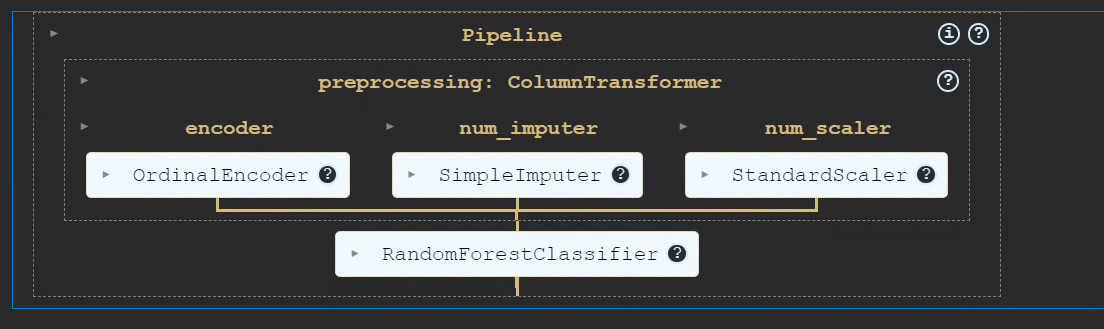

**EVALUTION DU MODEL**

Évaluez les performances du modèle en calculant à la fois l'exactitude et le score F1.

In [6]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

predictions = pipe.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average='weighted')
print ( "Accuracy:", str(round(accuracy, 2) *100) + "%" + " F1 Score:", str(round(f1, 2)))

Accuracy: 95.0% F1 Score: 0.95


In [7]:
with open("Results/metrics.txt", "w") as outfile:
    outfile.write(f"\nAccuracy = {accuracy.round(2)}, F1 Score = {f1.round(2)}.")

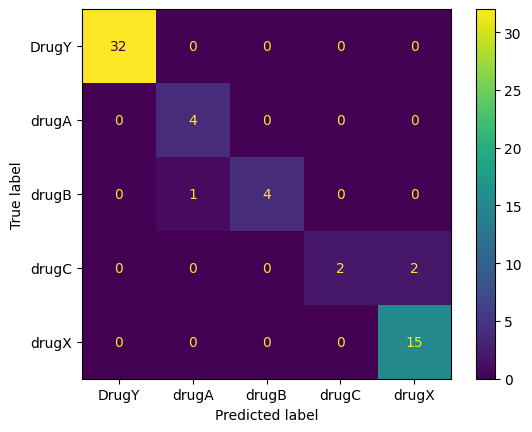

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, predictions, labels=pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot()
plt.savefig("Results/model_results.png", dpi=120)

**Saving Model**

In [10]:
 !pip install skops

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 KB 3.0 MB/s eta 0:00:00a 0:00:01


In [11]:
import skops.io as sio

sio.dump(pipe, "Model/drug_pipeline.skops")

In [16]:
untrusted_types = sio.get_untrusted_types(file="Model/drug_pipeline.skops")
sio.load("Model/drug_pipeline.skops", trusted=untrusted_types)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('encoder', OrdinalEncoder(),
                                                  [1, 2, 3]),
                                                 ('num_imputer',
                                                  SimpleImputer(strategy='median'),
                                                  [0, 4]),
                                                 ('num_scaler',
                                                  StandardScaler(), [0, 4])])),
                ('model', RandomForestClassifier(random_state=125))])